# Fine-Tuning Whisper-Medium on Hinglish (`ujs/hinglish-compressed`)

This notebook fine-tunes **OpenAI Whisper-Medium** on the Hinglish speech dataset from Hugging Face.

Key features:
- Dataset is already at **16 kHz** — no resampling needed
- **2 000 training samples** used for fine-tuning
- **50 held-out eval samples** used as a evaluation benchmark
- **WER & CER** calculated with the *base* model and the *fine-tuned* model to show improvement
- **WER vs Training Steps** plot generated after training
- Model saved locally (no Hub push required)

## 1. Install Dependencies

In [1]:
!pip install -q --upgrade pip
!pip install -q datasets==2.19.0 transformers accelerate evaluate jiwer soundfile librosa matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 39.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.


## 2. Imports

In [2]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dataclasses import dataclass
from typing import Any, Dict, List, Union

import datasets
from datasets import load_dataset, DatasetDict, Audio
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    WhisperFeatureExtractor,
    WhisperTokenizer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)
import evaluate

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


In [3]:
# CONFIGURATION FOR NOTEBOOK

CONFIG={
    'TRAIN_DATASET_DOWNLOAD_SIZE' : 5000,
    'TEST_DATASET_DOWNLOAD_SIZE' : 500,
    'TRAIN_SIZE' : 500,
    'EVAL_SIZE' : 100,
    'BENCHMARK_SIZE' : 50,
}

## 3. Load Dataset

We load `ujs/hinglish-compressed` from Hugging Face. The audio is **already at 16 kHz**, so no resampling step is needed.

- **Training set** : first 2000 samples
- **Benchmark set**: first 50 samples from the eval/test split (fixed, used before *and* after fine-tuning)

In [4]:
from datasets import load_dataset_builder

info = load_dataset_builder("ujs/hinglish-compressed")
print(info.info.splits)  # shows all available splits and their sizes

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


{'train': SplitInfo(name='train', num_bytes=1004369332, num_examples=52825, shard_lengths=[26500, 26200, 125], dataset_name='hinglish-compressed'), 'test': SplitInfo(name='test', num_bytes=58144454, num_examples=3136, shard_lengths=None, dataset_name='hinglish-compressed')}


In [5]:
# Load only the slices you need using split slicing
train_dataset = load_dataset(
    "ujs/hinglish-compressed",
    split="train[:5000]"
)
print(f"Train size: {len(train_dataset)}")

test_dataset = load_dataset(
    "ujs/hinglish-compressed",
    split="test[:500]"
)
print(f"Test size:  {len(test_dataset)}")

Generating train split:   0%|          | 0/52825 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3136 [00:00<?, ? examples/s]

Train size: 5000
Test size:  500


In [6]:
## 3. Load Dataset
train_split = 'train'
eval_split = 'test'
selected_train_dataset = train_dataset.select(range(CONFIG['TRAIN_SIZE']))
eval_dataset = test_dataset.select(range(CONFIG['EVAL_SIZE']))
benchmark_dataset = test_dataset.select(range(CONFIG['BENCHMARK_SIZE']))

print(f"\nTraining samples  : {len(selected_train_dataset)}")
print(f"Eval samples : {len(eval_dataset)}")
print(f"Benchmark samples : {len(benchmark_dataset)}")
print("\nSample entry:\n", train_dataset[0])


Training samples  : 500
Eval samples : 100
Benchmark samples : 50

Sample entry:
 {'path': 'train/100051_GigsEKRBMhvNwolC_0000.wav', 'audio': {'path': '100051_GigsEKRBMhvNwolC_0000.wav', 'array': array([-5.83425299e-06, -1.20940240e-06, -6.48457808e-06, ...,
       -6.77683602e-06, -5.37258938e-06, -1.92017251e-05]), 'sampling_rate': 16000}, 'sentence': 'दोस्तों bash में nested और multilevel if statement के spoken tutorial में आपका स्वागत है'}


## 4. Load Whisper Processor

`WhisperProcessor` bundles the **feature extractor** (audio → log-Mel spectrogram) and the **tokenizer** (text ↔ token ids).
We configure both for Hinglish — using `Hindi` as the language tag since Whisper does not have a dedicated Hinglish tag.

In [7]:
MODEL_ID = "openai/whisper-medium"

processor = WhisperProcessor.from_pretrained(MODEL_ID, language="Hindi", task="transcribe")
feature_extractor = processor.feature_extractor
tokenizer         = processor.tokenizer

print("Processor loaded from:", MODEL_ID)

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Processor loaded from: openai/whisper-medium


## 5. Detect Audio & Text Column Names

In [8]:
sample = train_dataset[0]

# Detect audio column
audio_col = None
for col in train_dataset.column_names:
    if isinstance(sample[col], dict) and "array" in sample[col]:
        audio_col = col
        break
if audio_col is None:
    raise ValueError("Could not auto-detect audio column. Check dataset structure.")

# Detect text/transcript column
candidate_text_cols = ["transcription", "sentence", "text", "transcript", "label", "hinglish"]
text_col = None
for col in candidate_text_cols:
    if col in train_dataset.column_names:
        text_col = col
        break
if text_col is None:
    # Fall back to first non-audio string column
    for col in train_dataset.column_names:
        if col != audio_col and isinstance(sample[col], str):
            text_col = col
            break
if text_col is None:
    raise ValueError("Could not auto-detect text column. Check dataset structure.")

print(f"Audio column : '{audio_col}'")
print(f"Text column  : '{text_col}'")
print(f"\nSample audio sampling_rate : {sample[audio_col]['sampling_rate']} Hz")
print(f"Sample transcript          : {sample[text_col]}")

Audio column : 'audio'
Text column  : 'sentence'

Sample audio sampling_rate : 16000 Hz
Sample transcript          : दोस्तों bash में nested और multilevel if statement के spoken tutorial में आपका स्वागत है


## 6. Prepare Dataset

Since the audio is already at **16 kHz** we skip resampling and go directly to:
1. Extract **log-Mel spectrogram** features from the audio array
2. Tokenize the transcript into **label ids**

In [9]:
def prepare_dataset(batch):
    audio = batch[audio_col]
    # Audio is already 16 kHz — pass sampling_rate for safety check
    batch["input_features"] = feature_extractor(
        audio["array"], sampling_rate=16000
    ).input_features[0]
    #print(batch['input_features'])
    batch["labels"] = tokenizer(batch[text_col]).input_ids
    #print(batch['labels'])
    return batch

cols_to_remove = [c for c in train_dataset.column_names]
print(f"columns to remove are {cols_to_remove}")

train_prepared     = train_dataset.map(prepare_dataset,     remove_columns=cols_to_remove, num_proc=2)
benchmark_prepared = benchmark_dataset.map(prepare_dataset, remove_columns=cols_to_remove, num_proc=2)
eval_prepared = eval_dataset.map(prepare_dataset, remove_columns=cols_to_remove, num_proc=2)

print("Prepared training samples  :", len(train_prepared))
print("Prepared benchmark samples :", len(benchmark_prepared))
print("Prepared eval samples :", len(eval_prepared))

columns to remove are ['path', 'audio', 'sentence']


Map (num_proc=2):   0%|          | 0/5000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/50 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/100 [00:00<?, ? examples/s]

Prepared training samples  : 5000
Prepared benchmark samples : 50
Prepared eval samples : 100


## 7. Data Collator

In [10]:
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    decoder_start_token_id: int

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch   = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        if (labels[:, 0] == self.decoder_start_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch

## 8. Load Whisper-Medium Model

In [11]:
model = WhisperForConditionalGeneration.from_pretrained(MODEL_ID)

# Configure model for training
# IMPORTANT: Set use_cache=False to prevent backward graph errors during training
model.config.use_cache = False  # Required to prevent "backward through graph second time" error
model.config.forced_decoder_ids = None
#model.config.suppress_tokens = []

model.generation_config.language = "Hindi"
model.generation_config.task     = "transcribe"
model.generation_config.forced_decoder_ids = None
model.generation_config.repetition_penalty = 1.2  # Penalize repetition (1.0 = no penalty, >1.0 = penalty)
model.generation_config.no_repeat_ngram_size = 3  # Prevent repeating 3-grams

data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor,
    decoder_start_token_id=model.config.decoder_start_token_id,
)

print("Model loaded. Parameters:", sum(p.numel() for p in model.parameters()) // 1_000_000, "M")
print("Generation config - repetition_penalty:", model.generation_config.repetition_penalty)
print("Generation config - no_repeat_ngram_size:", model.generation_config.no_repeat_ngram_size)
print("Model config - use_cache:", model.config.use_cache, "(False prevents backward graph errors)")
print("Model training mode:", model.training)

model.safetensors:   0%|          | 0.00/3.06G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Model loaded. Parameters: 763 M
Generation config - repetition_penalty: 1.2
Generation config - no_repeat_ngram_size: 3
Model config - use_cache: False (False prevents backward graph errors)
Model training mode: False


In [12]:
# OPTIONAL: Freeze Encoder to Save Memory (Recommended for CUDA OOM)
# The encoder is the largest part of Whisper and uses ~60% of model memory
# Freezing it can reduce memory usage by 50-60% while still allowing decoder fine-tuning

FREEZE_ENCODER = True  # Set to False for full fine-tuning (requires more memory)

# Freeze params in encoder layers 0-19 (keep only last 4 encoder layers)
ENCODER_LAYERS_TO_FREEZE = set(range(19))  # layers 0..19

if FREEZE_ENCODER:
    # Freeze all encoder parameters
    for name, param in model.named_parameters():
        if "encoder.layers." in name:
            layer_idx = int(name.split("encoder.layers.")[1].split(".")[0])
            #print(f"\n layer_idx is {layer_idx}")
            if layer_idx in ENCODER_LAYERS_TO_FREEZE:
                param.requires_grad = False

    #for param in model.model.encoder.parameters():
     #   param.requires_grad = False

    # Count trainable vs frozen parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params

    print(f"✅ Encoder frozen to save memory")
    print(f"   Total parameters    : {total_params / 1e6:.1f}M")
    print(f"   Trainable (decoder) : {trainable_params / 1e6:.1f}M")
    print(f"   Frozen (encoder)    : {frozen_params / 1e6:.1f}M")
    print(f"   Memory savings      : ~{frozen_params/total_params*100:.0f}%")
else:
    print("⚠️  Full fine-tuning enabled - requires more GPU memory")
    print(f"   Total parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M (all trainable)")


✅ Encoder frozen to save memory
   Total parameters    : 763.9M
   Trainable (decoder) : 474.2M
   Frozen (encoder)    : 289.7M
   Memory savings      : ~38%


## 9. Baseline Evaluation (Before Fine-Tuning)

We run inference on the **10 benchmark samples** using the vanilla `whisper-medium` checkpoint and compute **WER** and **CER**.

In [13]:
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def evaluate_model_on_benchmark(mdl, split_raw, label="Model", repetition_penalty=1.2, no_repeat_ngram_size=3):
    """
    Run greedy inference on benchmark samples and return WER, CER.

    Args:
        mdl: Model to evaluate
        split_raw: Raw dataset split
        label: Label for printing
        repetition_penalty: Penalty for repetition (>1.0 penalizes, 1.0 = no penalty)
        no_repeat_ngram_size: Prevent repeating n-grams of this size
    """
    mdl.eval()
    device = "cuda" if torch.cuda.is_available() else "cpu"
    mdl.to(device)

    predictions, references = [], []

    for sample in split_raw:
        audio_array = sample[audio_col]["array"]
        ref_text    = sample[text_col]

        input_feats = feature_extractor(
            audio_array, sampling_rate=16000, return_tensors="pt"
        ).input_features.to(device)

        with torch.no_grad():
            # Add repetition penalty parameters to reduce repetitive outputs
            predicted_ids = mdl.generate(
                input_feats,
                repetition_penalty=repetition_penalty,
                no_repeat_ngram_size=no_repeat_ngram_size,
                max_length=225,  # Set max length to prevent excessive generation
            )

        pred_text = tokenizer.batch_decode(predicted_ids, skip_special_tokens=True)[0]
        predictions.append(pred_text)
        references.append(ref_text)

    wer = 100 * wer_metric.compute(predictions=predictions, references=references)
    cer = 100 * cer_metric.compute(predictions=predictions, references=references)

    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"  Generation params: repetition_penalty={repetition_penalty}, no_repeat_ngram_size={no_repeat_ngram_size}")
    for i, (p, r) in enumerate(zip(predictions, references)):
        print(f"  [{i+1}] REF : {r}")
        print(f"       PRED: {p}")
    print(f"\n  WER: {wer:.2f}%")
    print(f"  CER: {cer:.2f}%")
    print(f"{'='*50}\n")

    return wer, cer, predictions, references

baseline_wer, baseline_cer, baseline_preds, benchmark_refs = evaluate_model_on_benchmark(
    model, eval_dataset, label="Baseline Whisper-Medium (Before Fine-Tuning)",
    repetition_penalty=1.2, no_repeat_ngram_size=3
)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA


  Baseline Whisper-Medium (Before Fine-Tuning)
  Generation params: repetition_penalty=1.2, no_repeat_ngram_size=3
  [1] REF : लिबर ऑफिस impress में एक प्रस्तुति document बनाना और बुनियादी formatting के इस spoken tutorial में आपका स्वागत है
       PRED:  लिबर आफस् इम्प्लेस में एक प्रस्तृती डोक्यूमेन भनाना और बुन्याली फॉर्मैटिंग के इस सपोगन्ट टिटूइर मेn आहका स्वागा
  [2] REF : इस tutorial में हम impress window के भागों के बारे में सीखेंगे और कैसे स्लाइड इन्सर्ट करें और कॉपी करें फॉन्ट तथा फॉन्ट को फॉर्मेट करना सीखेंगे
       PRED:  इस चीटुरल में हम इंप्रैस विन्डो के भागो कह बारे मे सीकेंगे और कैसे स्लाइड इनसर्ट करें औ़ो कोपी करते हैं. फॉंट तो था फ़ॉन्त को फार्मैटकर खरना सीखेंंघे
  [3] REF : यहाँ हम अपने ऑपरेटिंग सिस्टम के रूप में gnu/linux और लिबरऑफिस वर्जन 334 का उपयोग कर रहे हैं
       PRED:  यहां हम अपने Operating System के रूप में JNU Linux और LibreOffice version 3.3.4 का ओक्योक कर रहे हैं
  [4] REF : चलिए अपनी प्रस्तुति प्रेजैटेशन sample impress open करते हैं जिसे पिछले tutorial म

## 10. Metrics & WER Logger for Training

In [14]:
# Storage for WER at each eval step
wer_log = {"steps": [], "wer": []}

def compute_metrics(pred):
    pred_ids  = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = tokenizer.pad_token_id

    pred_str  = tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = 100 * wer_metric.compute(predictions=pred_str, references=label_str)
    return {"wer": wer}

## 11. Training Arguments

Key settings for Kaggle (typically a P100 or T4 GPU):
- `fp16=True` for mixed-precision training
- `gradient_checkpointing=True` to save VRAM
- Eval every **100 steps** so we capture a smooth WER curve
- 2 000 training samples with batch size 8 → ~250 steps per epoch

In [15]:
OUTPUT_DIR = "./whisper-medium-hinglish"

# Note: Repetition penalty is set on model.generation_config (see Cell 19)
# The trainer will use the model's generation_config during evaluation

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=1,       # Keep at 1 for memory efficiency
    gradient_accumulation_steps=4,       # Increase to maintain effective batch size = 4
    learning_rate=1e-5,
    warmup_steps=50,
    max_steps=400,
    gradient_checkpointing=True,         # ENABLED: Now safe with use_cache=False fix - saves ~40% memory
    fp16=True,                           # Mixed precision training - saves ~50% memory
    eval_strategy="steps",
    per_device_eval_batch_size=1,       # Reduced from 2 to save memory during eval
    predict_with_generate=True,
    generation_max_length=225,
    save_steps=50,
    eval_steps=50,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    push_to_hub=False,
    report_to=["none"],                  # disable external logging
    dataloader_pin_memory=False,        # Prevent memory issues
    remove_unused_columns=False,         # Keep all columns to avoid issues
    dataloader_num_workers=0,            # Reduce workers to save memory (0 = main process only)
)

print("Training arguments configured.")
print(f"  max_steps            : {training_args.max_steps}")
print(f"  eval_steps           : {training_args.eval_steps}")
print(f"  batch size (eff.)    : {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  output_dir           : {training_args.output_dir}")
print(f"  Note: Repetition penalty (1.2) set on model.generation_config for eval")

Training arguments configured.
  max_steps            : 400
  eval_steps           : 50
  batch size (eff.)    : 4
  output_dir           : ./whisper-medium-hinglish
  Note: Repetition penalty (1.2) set on model.generation_config for eval


## 12. Custom Callback — Log WER at Every Eval Step

In [16]:
from transformers import TrainerCallback

class WERLoggerCallback(TrainerCallback):
    """Captures WER at every evaluation step for plotting."""

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics and "eval_wer" in metrics:
            wer_log["steps"].append(state.global_step)
            wer_log["wer"].append(metrics["eval_wer"])
            print(f"  [Step {state.global_step}] eval WER = {metrics['eval_wer']:.2f}%")

## 13. Build Trainer

In [17]:
model.train()

trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=train_prepared,
    eval_dataset=benchmark_prepared,     # 50-sample benchmark used during training too
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[WERLoggerCallback()],
)

processor.save_pretrained(OUTPUT_DIR)
print("Trainer ready.")
print("Model training mode:", model.training)

Trainer ready.
Model training mode: True


## 14. Train!

In [18]:
train_result = trainer.train()
print("\nTraining complete.")
print(f"  Total steps   : {train_result.global_step}")
print(f"  Training loss : {train_result.training_loss:.4f}")

# Save the best checkpoint locally
trainer.save_model(OUTPUT_DIR)
print(f"\nModel saved to: {OUTPUT_DIR}")

Step,Training Loss,Validation Loss,Wer
50,3.091400,0.610629,49.927431
100,2.266370,0.513794,51.378810
150,1.973348,0.469701,44.847605
200,1.727918,0.449568,47.169811
250,1.428566,0.457255,46.734398
300,1.723273,0.414806,44.847605
350,1.535526,0.403755,42.235123
400,1.386680,0.399902,40.203193


  [Step 50] eval WER = 49.93%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [Step 100] eval WER = 51.38%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['proj_out.weight'].



Training complete.
  Total steps   : 400
  Training loss : 1.8916


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to: ./whisper-medium-hinglish


## 15. WER vs Training Steps

A lower WER means the model is getting better at transcribing Hinglish. The plot below shows how evaluation WER evolves over training.

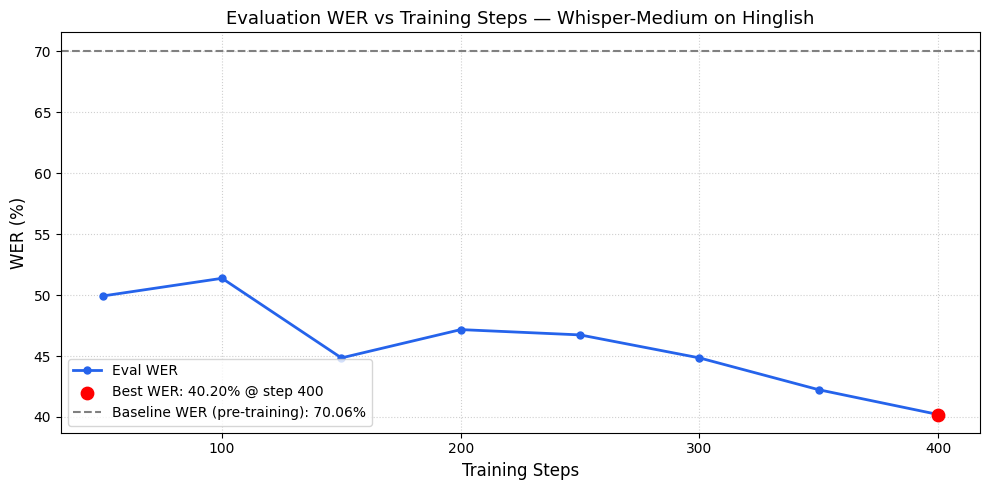

Plot saved to: ./whisper-medium-hinglish/wer_vs_steps.png


In [19]:
if wer_log["steps"]:
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(wer_log["steps"], wer_log["wer"],
            marker="o", linewidth=2, markersize=5, color="#2563EB", label="Eval WER")

    # Mark best (minimum) WER
    best_idx = int(np.argmin(wer_log["wer"]))
    ax.scatter(wer_log["steps"][best_idx], wer_log["wer"][best_idx],
               color="red", zorder=5, s=80, label=f"Best WER: {wer_log['wer'][best_idx]:.2f}% @ step {wer_log['steps'][best_idx]}")

    # Baseline reference line
    ax.axhline(baseline_wer, linestyle="--", color="gray", linewidth=1.5,
               label=f"Baseline WER (pre-training): {baseline_wer:.2f}%")

    ax.set_xlabel("Training Steps", fontsize=12)
    ax.set_ylabel("WER (%)", fontsize=12)
    ax.set_title("Evaluation WER vs Training Steps — Whisper-Medium on Hinglish", fontsize=13)
    ax.legend(fontsize=10)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
    ax.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "wer_vs_steps.png"), dpi=150)
    plt.show()
    print("Plot saved to:", os.path.join(OUTPUT_DIR, "wer_vs_steps.png"))
else:
    print("No WER log entries found. Training may not have completed an eval step.")

## 16. Post Fine-Tuning Evaluation (After Training)

Reload the best checkpoint and run the same 10-sample benchmark again.

In [20]:
# Reload best checkpoint
finetuned_model = WhisperForConditionalGeneration.from_pretrained(OUTPUT_DIR)
# Ensure repetition penalty is set for fine-tuned model evaluation
finetuned_model.generation_config.repetition_penalty = 1.2
finetuned_model.generation_config.no_repeat_ngram_size = 3

finetuned_wer, finetuned_cer, finetuned_preds, _ = evaluate_model_on_benchmark(
    finetuned_model, eval_dataset, label="Fine-Tuned Whisper-Medium (After Training)",
    repetition_penalty=1.2, no_repeat_ngram_size=3
)

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]


  Fine-Tuned Whisper-Medium (After Training)
  Generation params: repetition_penalty=1.2, no_repeat_ngram_size=3
  [1] REF : लिबर ऑफिस impress में एक प्रस्तुति document बनाना और बुनियादी formatting के इस spoken tutorial में आपका स्वागत है
       PRED: libber office impress में एक प्रस्तुती document बनाना और बूनियादी formatting के इस spoken tutorial मेn आपका स्वागत हो
  [2] REF : इस tutorial में हम impress window के भागों के बारे में सीखेंगे और कैसे स्लाइड इन्सर्ट करें और कॉपी करें फॉन्ट तथा फॉन्ट को फॉर्मेट करना सीखेंगे
       PRED: इस tutorial में हम impressed window के भागों के सीखेंगे और कैसे slide insert करें औऱ copy करनें font तथा font को format करता सीकें
  [3] REF : यहाँ हम अपने ऑपरेटिंग सिस्टम के रूप में gnu/linux और लिबरऑफिस वर्जन 334 का उपयोग कर रहे हैं
       PRED: यहाँ हम अपने operating system के रूप में jnu linux और libreoffice version 334 का उक्योग कर रहे हैं
  [4] REF : चलिए अपनी प्रस्तुति प्रेजैटेशन sample impress open करते हैं जिसे पिछले tutorial में बनाया था
       P

## 17. WER & CER Comparison: Before vs After Fine-Tuning

In [21]:
print("\n" + "="*60)
print(f"{'Metric':<20} {'Baseline':>15} {'Fine-Tuned':>15} {'Improvement':>12}")
print("-"*60)

wer_improvement = baseline_wer - finetuned_wer
cer_improvement = baseline_cer - finetuned_cer

print(f"{'WER (%)':<20} {baseline_wer:>15.2f} {finetuned_wer:>15.2f} {wer_improvement:>+12.2f}")
print(f"{'CER (%)':<20} {baseline_cer:>15.2f} {finetuned_cer:>15.2f} {cer_improvement:>+12.2f}")
print("="*60)
print("(Negative improvement = higher error after tuning — train longer or adjust LR)")


Metric                      Baseline      Fine-Tuned  Improvement
------------------------------------------------------------
WER (%)                        70.06           35.99       +34.08
CER (%)                        54.34           26.68       +27.66
(Negative improvement = higher error after tuning — train longer or adjust LR)


## 18. Visualise Before vs After

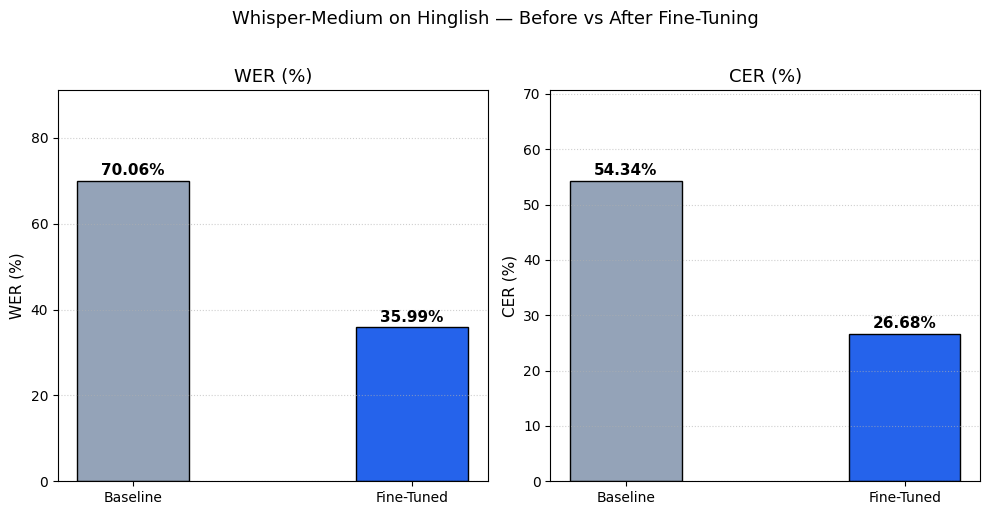

Comparison chart saved to: ./whisper-medium-hinglish/wer_cer_comparison.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, metric_name, before, after in zip(
    axes,
    ["WER (%)", "CER (%)"],
    [baseline_wer, baseline_cer],
    [finetuned_wer, finetuned_cer],
):
    bars = ax.bar(["Baseline", "Fine-Tuned"], [before, after],
                  color=["#94A3B8", "#2563EB"], width=0.4, edgecolor="black")
    for bar, val in zip(bars, [before, after]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.2f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_title(metric_name, fontsize=13)
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_ylim(0, max(before, after) * 1.3)
    ax.grid(axis="y", linestyle=":", alpha=0.6)

plt.suptitle("Whisper-Medium on Hinglish — Before vs After Fine-Tuning", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "wer_cer_comparison.png"), dpi=150)
plt.show()
print("Comparison chart saved to:", os.path.join(OUTPUT_DIR, "wer_cer_comparison.png"))

## 19. Sample-by-Sample Transcript Comparison

In [23]:
print(f"{'#':<4} {'Reference':<40} {'Baseline Pred':<40} {'Fine-Tuned Pred':<40}")
print("-" * 124)
for i, (ref, bp, fp) in enumerate(zip(benchmark_refs, baseline_preds, finetuned_preds), 1):
    ref_ = ref[:38]  + ".." if len(ref)  > 40 else ref
    bp_  = bp[:38]   + ".." if len(bp)   > 40 else bp
    fp_  = fp[:38]   + ".." if len(fp)   > 40 else fp
    print(f"{i:<4} {ref_:<40} {bp_:<40} {fp_:<40}")

#    Reference                                Baseline Pred                            Fine-Tuned Pred                         
----------------------------------------------------------------------------------------------------------------------------
1    लिबर ऑफिस impress में एक प्रस्तुति doc..  लिबर आफस् इम्प्लेस में एक प्रस्तृती ड.. libber office impress में एक प्रस्तुती..
2    इस tutorial में हम impress window के भ..  इस चीटुरल में हम इंप्रैस विन्डो के भा.. इस tutorial में हम impressed window के..
3    यहाँ हम अपने ऑपरेटिंग सिस्टम के रूप मे..  यहां हम अपने Operating System के रूप .. यहाँ हम अपने operating system के रूप म..
4    चलिए अपनी प्रस्तुति प्रेजैटेशन sample ..  जब इसकारे किना प्रस्तुती सैमपल एंप्डर.. चलिये अपनी प्रस्तुती sample impressed ..
5    चलिए देखते हैं कि screen पर क्या क्या है  जब देते हैं कि स्कॉरीन पर क्या क्षा है  चलिए देटते हैं कि screen पर क्या क््यa..
6    मध्य में हम खाली जगह देखते है जोकि wor..  पराइक्यूंगे को लिए ज़िन्माची तो आप बह.. मध्य में हम खाली जगह